# Customer Churn Prediction: Complete ML Workflow

This notebook builds an auditable churn workflow for the Telco Customer Churn dataset. It covers data quality, leakage-safe preprocessing, two supervised models, rigorous evaluation, and three unsupervised segmentation methods.

## 1. Imports and reproducibility

The CSV is loaded from the same folder as this notebook. A fixed random seed makes the train/test split, models, and clustering reproducible.

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, silhouette_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='colorblind')

## 2. Load, inspect, and clean the data

`TotalCharges` is read as text because the source contains blank strings. We replace whitespace-only values with `NaN`, then convert the column to numeric. The identifier is removed because it has no predictive meaning.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

relative_path = Path('WA_Fn-UseC_-Telco-Customer-Churn.csv')
if not relative_path.exists():
    raise FileNotFoundError(
        f'Could not find {relative_path.resolve()}. Open the notebook from the dataset folder '
        'or update relative_path to the CSV location.'
    )
data_path = relative_path
df = pd.read_csv(data_path)
print(f'Shape: {df.shape}')
display(df.head())
print('Raw dtypes:')
display(df.dtypes.to_frame('dtype'))

blank_total_charges = df['TotalCharges'].astype(str).str.strip().eq('').sum()
df['TotalCharges'] = (df['TotalCharges'].astype(str).str.strip()
                      .replace('', np.nan).pipe(pd.to_numeric, errors='coerce'))
print(f'Blank TotalCharges values converted to NaN: {blank_total_charges}')
print('Missing values after conversion:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_count'))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Raw dtypes:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Blank TotalCharges values converted to NaN: 11
Missing values after conversion:


,missing_count
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target balance:


,count
Churn,
No,5174
Yes,1869


,percent
Churn,
No,73.46
Yes,26.54


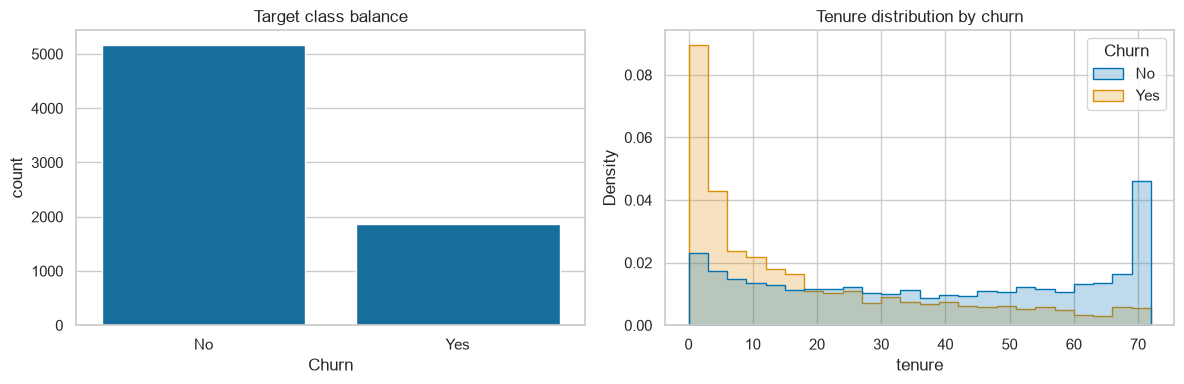

In [6]:
target = 'Churn'
X = df.drop(columns=[target, 'customerID']).copy()
y = df[target].map({'No': 0, 'Yes': 1})

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target balance:')
display(y.map({0: 'No', 1: 'Yes'}).value_counts(normalize=False).rename('count').to_frame())
display(y.map({0: 'No', 1: 'Yes'}).value_counts(normalize=True).mul(100).round(2).rename('percent').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y.map({0: 'No', 1: 'Yes'}), ax=axes[0])
axes[0].set_title('Target class balance')
axes[0].set_xlabel('Churn')
sns.histplot(data=df, x='tenure', hue='Churn', bins=24, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Tenure distribution by churn')
plt.tight_layout()

## 3. Feature engineering and preprocessing

Two domain features are added: `tenure_bucket` captures lifecycle stage, and `charges_per_tenure_month` approximates average monthly spend over observed tenure. The latter uses a one-month denominator for brand-new customers to avoid division by zero.

Numeric missing values use the median because it is robust to skew and extreme charges. Categorical missing values use the most frequent category. Scaling is applied only to numeric columns; one-hot encoding handles nominal categories and ignores unseen test categories. All fitting occurs inside the pipeline to prevent leakage.

In [7]:
class TelcoFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        transformed = X.copy()
        transformed['tenure_bucket'] = pd.cut(
            transformed['tenure'], bins=[-1, 12, 24, 48, np.inf],
            labels=['0-12 months', '13-24 months', '25-48 months', '49+ months']
        ).astype('object')
        transformed['charges_per_tenure_month'] = (
            transformed['TotalCharges'] / transformed['tenure'].clip(lower=1)
        )
        return transformed

engineered_numeric = numeric_features + ['charges_per_tenure_month']
engineered_categorical = categorical_features + ['tenure_bucket']
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, engineered_numeric),
    ('categorical', categorical_transformer, engineered_categorical)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')

Train rows: 5,634; test rows: 1,409


## 4. Supervised pipelines and cross-validation

Both models use the identical preprocessing pipeline. `class_weight='balanced'` increases the relative importance of churn cases during fitting, which is appropriate when recall matters and the positive class is smaller.

In [8]:
models = {
    'Logistic Regression': Pipeline([
        ('features', TelcoFeatureEngineer()),
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('features', TelcoFeatureEngineer()),
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'Model': name, 'CV ROC-AUC mean': scores.mean(), 'CV ROC-AUC std': scores.std()})
cv_results = pd.DataFrame(cv_rows).sort_values('CV ROC-AUC mean', ascending=False)
display(cv_results.style.format({'CV ROC-AUC mean': '{:.3f}', 'CV ROC-AUC std': '{:.3f}'}))

,Model,CV ROC-AUC mean,CV ROC-AUC std
0,Logistic Regression,0.846,0.011
1,Random Forest,0.839,0.008



Logistic Regression classification report
              precision    recall  f1-score   support

    No churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409


Random Forest classification report
              precision    recall  f1-score   support

    No churn       0.88      0.79      0.83      1035
       Churn       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.500,0.794,0.614,0.842
1,Random Forest,0.548,0.717,0.621,0.835


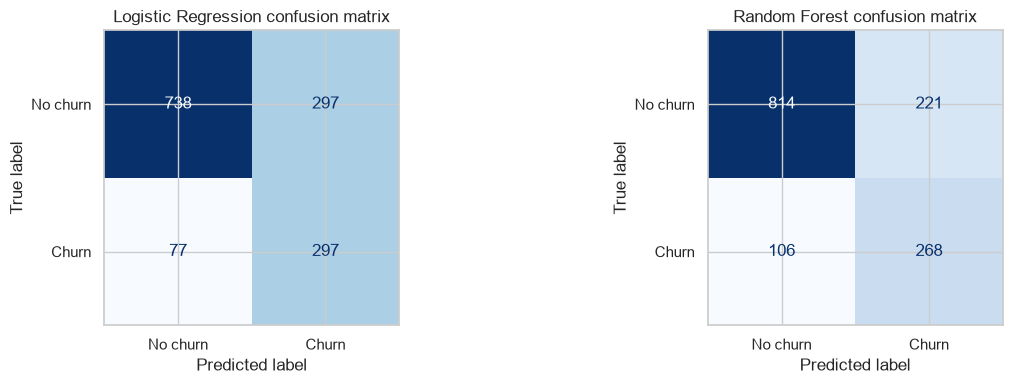

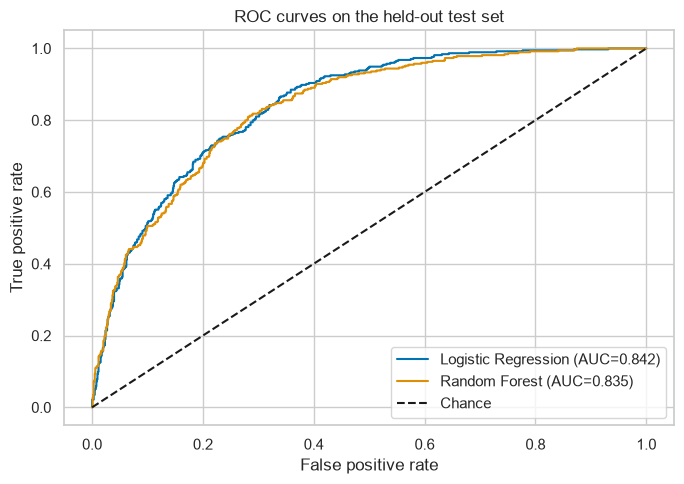

In [9]:
evaluation_rows = []
fitted_models = {}
fig, axes = plt.subplots(1, len(models), figsize=(13, 4))

for axis, (name, pipeline) in zip(axes, models.items()):
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    evaluation_rows.append({
        'Model': name,
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    })
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['No churn', 'Churn'], cmap='Blues', ax=axis, colorbar=False)
    axis.set_title(f'{name} confusion matrix')
    print(f'\n{name} classification report')
    print(classification_report(y_test, predictions, target_names=['No churn', 'Churn']))

plt.tight_layout()
evaluation = pd.DataFrame(evaluation_rows).sort_values('ROC-AUC', ascending=False)
display(evaluation.style.format('{:.3f}', subset=['Precision', 'Recall', 'F1', 'ROC-AUC']))

plt.figure(figsize=(7, 5))
for name, pipeline in fitted_models.items():
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, probabilities):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves on the held-out test set'); plt.legend(); plt.tight_layout()

### Model choice

The table above is the evidence for deployment selection. ROC-AUC measures ranking quality across thresholds, while recall and F1 show how well the model identifies the minority churn class at the default threshold. In a retention setting, I would deploy the model with the strongest cross-validated ROC-AUC and a useful churn recall/F1 trade-off, then tune its probability threshold against the cost of contacting a customer versus missing a likely churner.

,importance_or_coefficient
numeric__tenure,-0.999945
categorical__Contract_Two year,-0.844013
categorical__InternetService_Fiber optic,0.742188
categorical__Contract_Month-to-month,0.700950
categorical__InternetService_DSL,-0.644648
numeric__MonthlyCharges,-0.524789
categorical__tenure_bucket_13-24 months,-0.375809
categorical__tenure_bucket_49+ months,0.324784
categorical__StreamingMovies_Yes,0.296939
categorical__StreamingTV_Yes,0.285115


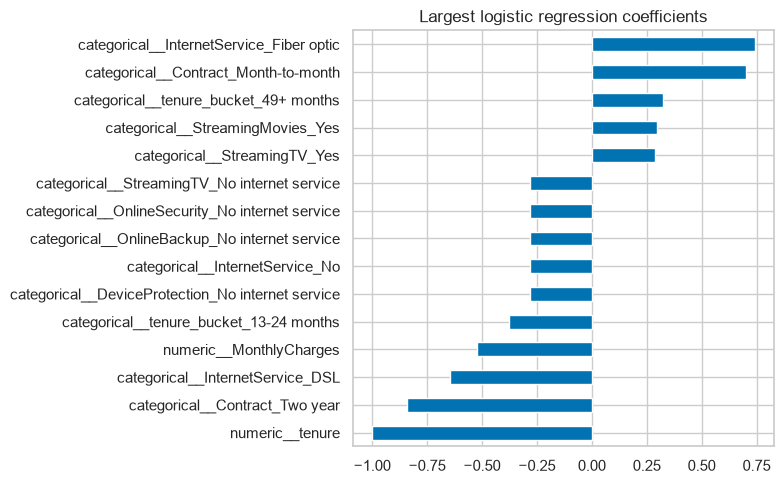

In [10]:
best_name = evaluation.iloc[0]['Model']
best_model = fitted_models[best_name]
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
estimator = best_model.named_steps['model']
if hasattr(estimator, 'coef_'):
    importance = pd.Series(estimator.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)
    importance.head(15).sort_values().plot(kind='barh', figsize=(8, 5), title='Largest logistic regression coefficients')
else:
    importance = pd.Series(estimator.feature_importances_, index=feature_names).sort_values(ascending=False)
    importance.head(15).sort_values().plot(kind='barh', figsize=(8, 5), title='Largest random forest importances')
plt.tight_layout()
display(importance.head(15).to_frame('importance_or_coefficient'))

## 5. Customer segmentation

For clustering, the target and customer ID are excluded. The fitted feature transformer creates a numeric, imputed, scaled, one-hot representation without using churn labels. PCA provides a common 2D visualization for all algorithms.

In [11]:
feature_only_pipeline = Pipeline([('features', TelcoFeatureEngineer()), ('preprocess', preprocessor)])
X_all_transformed = feature_only_pipeline.fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all_transformed)
print(f'Transformed feature matrix: {X_all_transformed.shape}')
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

Transformed feature matrix: (7043, 50)
PCA variance explained: 47.9%


### K-Means: elbow and silhouette selection

The elbow plot shows diminishing within-cluster sum of squares. Silhouette score adds a separation/compactness criterion; the selected `k` is the best-scoring candidate in this small search.

Selected k=2 with silhouette=0.249


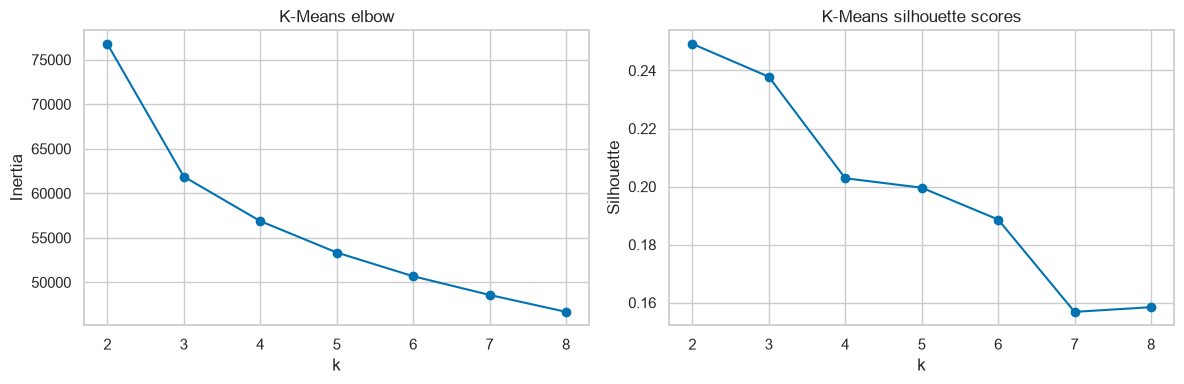

In [12]:
k_values = range(2, 9)
inertias, silhouettes = [], []
for k in k_values:
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(X_all_transformed)
    inertias.append(candidate.inertia_)
    silhouettes.append(silhouette_score(X_all_transformed, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, marker='o'); axes[0].set_title('K-Means elbow'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_values), silhouettes, marker='o'); axes[1].set_title('K-Means silhouette scores'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
selected_k = list(k_values)[int(np.argmax(silhouettes))]
kmeans = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_all_transformed)
print(f'Selected k={selected_k} with silhouette={max(silhouettes):.3f}')

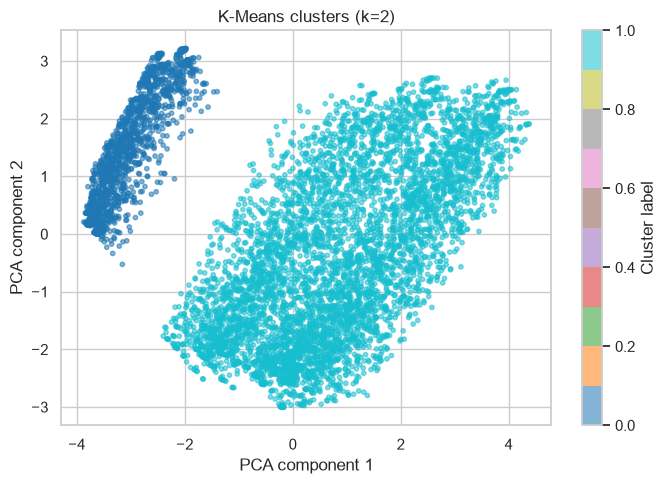

In [13]:
def plot_clusters(labels, title):
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10, alpha=0.55)
    plt.xlabel('PCA component 1'); plt.ylabel('PCA component 2'); plt.title(title)
    plt.colorbar(scatter, label='Cluster label'); plt.tight_layout()

plot_clusters(kmeans_labels, f'K-Means clusters (k={selected_k})')

### Hierarchical clustering and dendrogram

A dendrogram on a representative sample keeps the plot readable while showing how Ward linkage merges customers. The cut uses the K-Means-selected number of groups for a comparable profile.

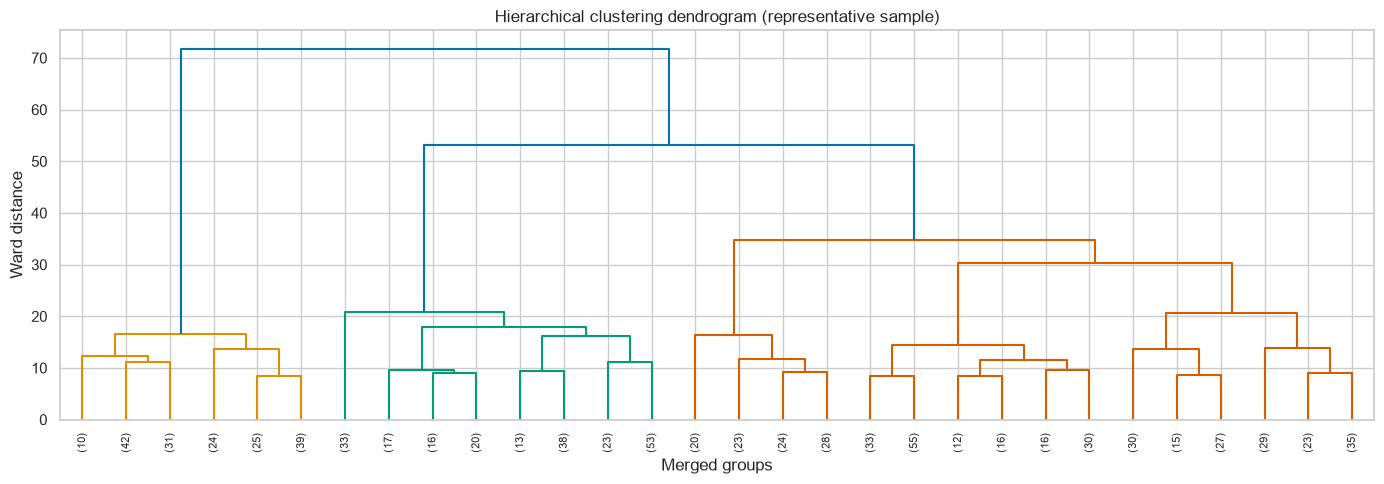

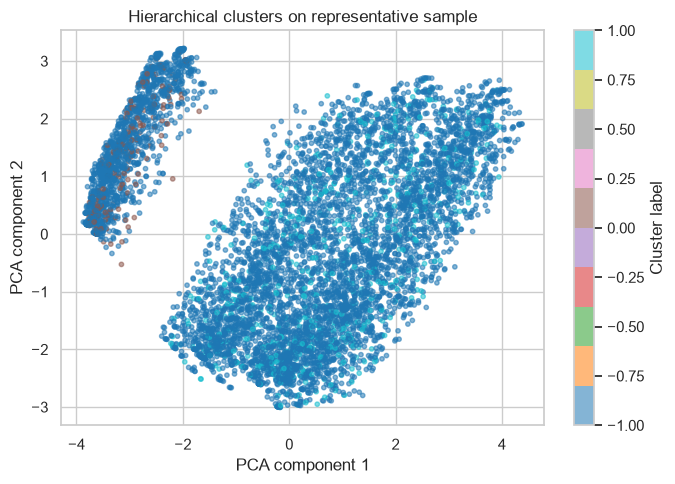

In [14]:
sample_size = min(800, len(X_all_transformed))
sample_rng = np.random.default_rng(RANDOM_STATE)
sample_indices = sample_rng.choice(len(X_all_transformed), size=sample_size, replace=False)
hierarchical_linkage = linkage(X_all_transformed[sample_indices], method='ward')
plt.figure(figsize=(14, 5))
dendrogram(hierarchical_linkage, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical clustering dendrogram (representative sample)'); plt.xlabel('Merged groups'); plt.ylabel('Ward distance'); plt.tight_layout()

from scipy.cluster.hierarchy import fcluster
hierarchical_sample_labels = fcluster(hierarchical_linkage, t=selected_k, criterion='maxclust') - 1
hierarchical_labels = np.full(len(X), -1, dtype=int)
hierarchical_labels[sample_indices] = hierarchical_sample_labels
plot_clusters(hierarchical_labels, 'Hierarchical clusters on representative sample')

### DBSCAN

DBSCAN identifies dense regions and does not require a chosen number of clusters. `-1` denotes noise. The small parameter grid below selects the candidate with the best silhouette score among configurations that produce at least two non-noise clusters; noise is excluded from that score.

Best DBSCAN: eps=1.2, min_samples=20, silhouette=0.897
DBSCAN clusters excluding noise: 5
DBSCAN noise points: 6839 (97.1%)


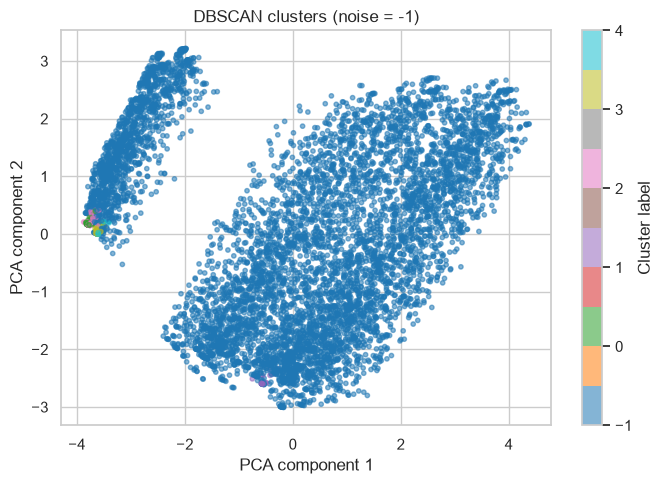

In [15]:
dbscan_candidates = []
for eps in [0.8, 1.0, 1.2, 1.5, 1.8]:
    for min_samples in [5, 10, 20]:
        candidate = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        candidate_labels = candidate.fit_predict(X_all_transformed)
        non_noise = candidate_labels != -1
        cluster_count = len(set(candidate_labels[non_noise]))
        if cluster_count >= 2 and non_noise.sum() > cluster_count:
            score = silhouette_score(X_all_transformed[non_noise], candidate_labels[non_noise])
            dbscan_candidates.append((score, eps, min_samples, cluster_count, (~non_noise).sum()))

dbscan_candidates.sort(reverse=True)
if dbscan_candidates:
    best_score, best_eps, best_min_samples, _, _ = dbscan_candidates[0]
    dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
    dbscan_labels = dbscan.fit_predict(X_all_transformed)
    print(f'Best DBSCAN: eps={best_eps}, min_samples={best_min_samples}, silhouette={best_score:.3f}')
else:
    dbscan_labels = np.full(len(X), -1)
    print('No DBSCAN configuration produced two non-noise clusters; all points are shown as noise.')

print(f'DBSCAN clusters excluding noise: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}')
print(f'DBSCAN noise points: {(dbscan_labels == -1).sum()} ({(dbscan_labels == -1).mean():.1%})')
plot_clusters(dbscan_labels, 'DBSCAN clusters (noise = -1)')

## 6. Cluster profiling and business interpretation

The profiles below join cluster labels back to the original customer records. Cluster churn rates are descriptive, not proof that clustering predicts churn: the algorithms did not see `Churn` while forming groups. A useful segment is one that is both behaviorally coherent and actionable.

In [16]:
profile = df.copy()
profile['churn_flag'] = y
profile['kmeans_cluster'] = kmeans_labels
profile['dbscan_cluster'] = dbscan_labels
cluster_profile = profile.groupby('kmeans_cluster').agg(
    customers=('customerID', 'size'),
    churn_rate=('churn_flag', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean')
).sort_values('churn_rate', ascending=False)
display(cluster_profile.style.format({'churn_rate': '{:.1%}', 'avg_tenure': '{:.1f}', 'avg_monthly_charges': '${:.2f}', 'avg_total_charges': '${:.2f}'}))

dbscan_profile = profile.groupby('dbscan_cluster').agg(
    customers=('customerID', 'size'), churn_rate=('churn_flag', 'mean'),
    avg_tenure=('tenure', 'mean'), avg_monthly_charges=('MonthlyCharges', 'mean')
).sort_values('churn_rate', ascending=False)
display(dbscan_profile.style.format({'churn_rate': '{:.1%}', 'avg_tenure': '{:.1f}', 'avg_monthly_charges': '${:.2f}'}))

,customers,churn_rate,avg_tenure,avg_monthly_charges,avg_total_charges
kmeans_cluster,,,,,
1,5517,31.8%,32.9,$76.84,$2729.51
0,1526,7.4%,30.5,$21.08,$665.22


,customers,churn_rate,avg_tenure,avg_monthly_charges
dbscan_cluster,,,,
1,24,70.8%,2.8,$69.72
3,26,34.6%,3.0,$19.73
4,24,33.3%,3.1,$20.11
-1,6839,26.4%,33.2,$65.92
0,70,25.7%,2.7,$20.03
2,60,21.7%,3.7,$19.96
